In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
root_folder_1 = 'datasets_train_final/training/'
root_folder_2 = 'datasets_train_final/validation/'
classes = [
        d
        for d in os.listdir(root_folder_1)
        if os.path.isdir(os.path.join(root_folder_1, d))
    ]
classes_to_idx = {class_name: i for i, class_name in enumerate(classes)}

file_paths = []
file_labels = []
for class_name in classes:
    class_folder_1 = os.path.join(root_folder_1, class_name)
    class_folder_2 = os.path.join(root_folder_2, class_name)
    for file_name in os.listdir(class_folder_1):
        if file_name.endswith('.npz'):
            file_paths.append(os.path.join(class_folder_1, file_name))
            file_labels.append(classes_to_idx[class_name])
    for file_name in os.listdir(class_folder_2):
        if file_name.endswith('.npz'):
            file_paths.append(os.path.join(class_folder_2, file_name))
            file_labels.append(classes_to_idx[class_name])

In [ ]:
aneu_mean = []
aneu_std = []
aneu_max = []
aneu_min = []
aneu_label = []

vessel_mean = []
vessel_std = []
vessel_max = []
vessel_min = []
vessel_label = []

for file_path, file_label in zip(file_paths, file_labels):
    data_npz = np.load(file_path)
    feats = data_npz['feats']
    coords = data_npz['coords']

    mean = np.mean(feats, axis=0)
    std = np.std(feats, axis=0)
    maxi = np.max(feats, axis=0)
    mini = np.min(feats, axis=0)

    if file_label == 0:
        aneu_mean.append(mean)
        aneu_std.append(std)
        aneu_max.append(maxi)
        aneu_min.append(mini)
        aneu_label.append(file_label)
    else:
        vessel_mean.append(mean)
        vessel_std.append(std)
        vessel_max.append(maxi)
        vessel_min.append(mini)
        vessel_label.append(file_label)


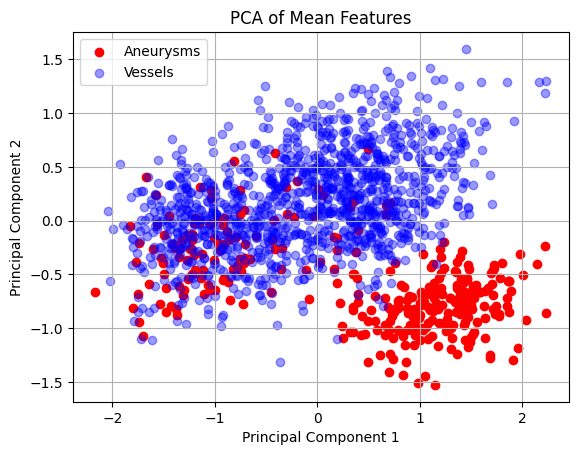

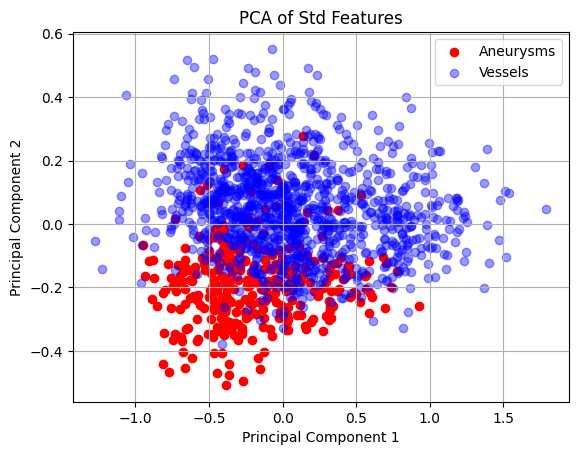

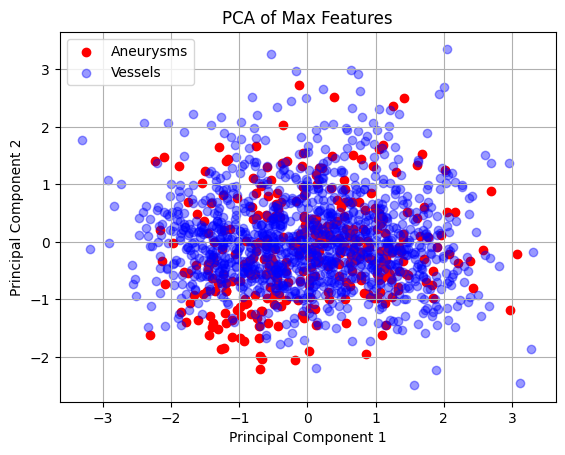

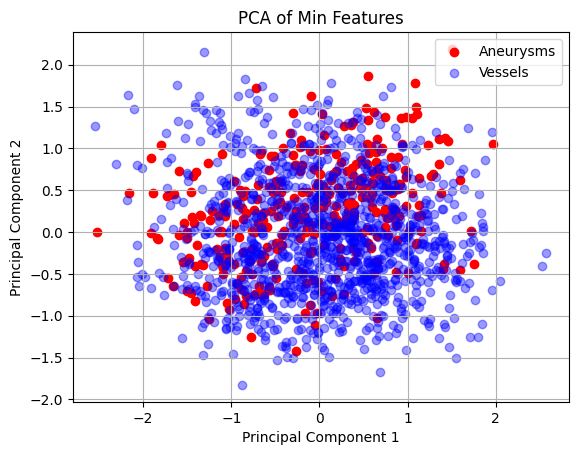

In [16]:
from sklearn.decomposition import PCA

# Combine the mean features for aneurysms and vessels
mean_features = aneu_mean + vessel_mean
std_features = aneu_std + vessel_std
max_features = aneu_max + vessel_max
min_features = aneu_min + vessel_min
labels = [0] * len(aneu_mean) + [1] * len(vessel_mean)  # 0 for aneurysms, 1 for vessels

# Perform PCA
pca_1 = PCA(n_components=2)
pca_2 = PCA(n_components=2)
pca_3 = PCA(n_components=2)
pca_4 = PCA(n_components=2)
pca_result_1 = pca_1.fit_transform(mean_features)
pca_result_2 = pca_2.fit_transform(std_features)
pca_result_3 = pca_3.fit_transform(max_features)
pca_result_4 = pca_4.fit_transform(min_features)

labels = np.array(labels)  # Convertir en array numpy

for pca_result, title in zip(
    [pca_result_1, pca_result_2, pca_result_3, pca_result_4],
    ['PCA of Mean Features', 'PCA of Std Features', 'PCA of Max Features', 'PCA of Min Features']
):
    for label, color, name, alpha in zip([0, 1], ['red', 'blue'], ['Aneurysms', 'Vessels'], [1.0, 0.4]):
        plt.scatter(
            pca_result[labels == label, 0],  # X
            pca_result[labels == label, 1],  # Y
            c=color, label=name, alpha=alpha
        )

    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.grid()
    plt.show()

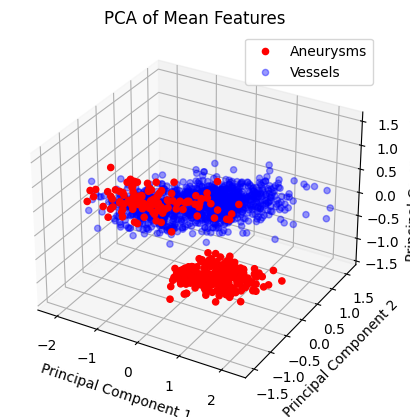

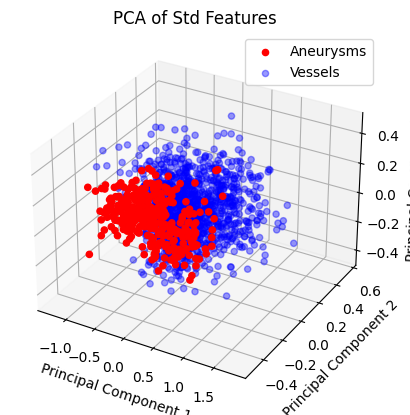

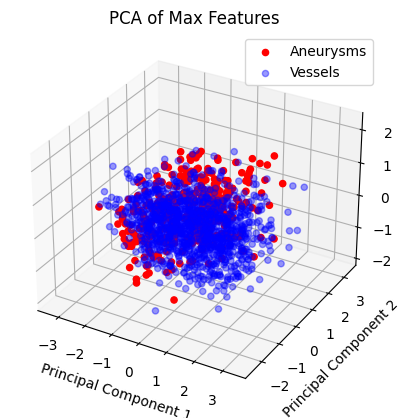

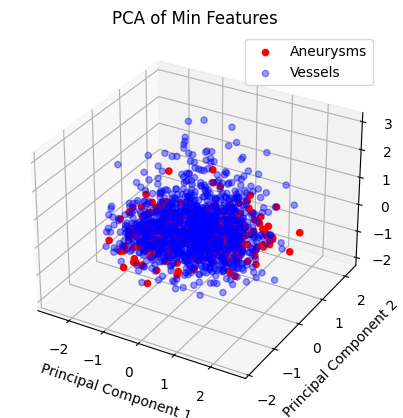

In [ ]:
from sklearn.decomposition import PCA

# Combine the mean features for aneurysms and vessels
mean_features = aneu_mean + vessel_mean
std_features = aneu_std + vessel_std
max_features = aneu_max + vessel_max
min_features = aneu_min + vessel_min
labels = [0] * len(aneu_mean) + [1] * len(vessel_mean)  # 0 for aneurysms, 1 for vessels

# Perform PCA
pca_1 = PCA(n_components=3)
pca_2 = PCA(n_components=3)
pca_3 = PCA(n_components=3)
pca_4 = PCA(n_components=3)
pca_result_1 = pca_1.fit_transform(mean_features)
pca_result_2 = pca_2.fit_transform(std_features)
pca_result_3 = pca_3.fit_transform(max_features)
pca_result_4 = pca_4.fit_transform(min_features)

labels = np.array(labels)  # Convertir en array numpy

for pca_result, title in zip(
    [pca_result_1, pca_result_2, pca_result_3, pca_result_4],
    ['PCA of Mean Features', 'PCA of Std Features', 'PCA of Max Features', 'PCA of Min Features']
):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    for label, color, name, alpha in zip([0, 1], ['red', 'blue'], ['Aneurysms', 'Vessels'], [1.0, 0.4]):
        ax.scatter(
            pca_result[labels == label, 0],  # X
            pca_result[labels == label, 1],  # Y
            pca_result[labels == label, 2],  # Z
            c=color, label=name, alpha=alpha
        )

    ax.set_title(title)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Principal Component 3')
    plt.legend()
    plt.show()